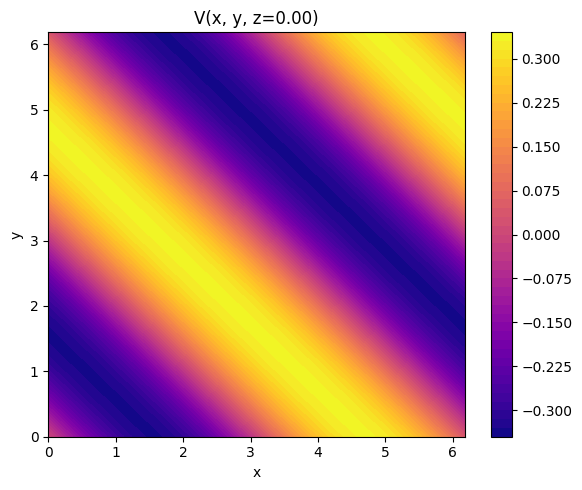

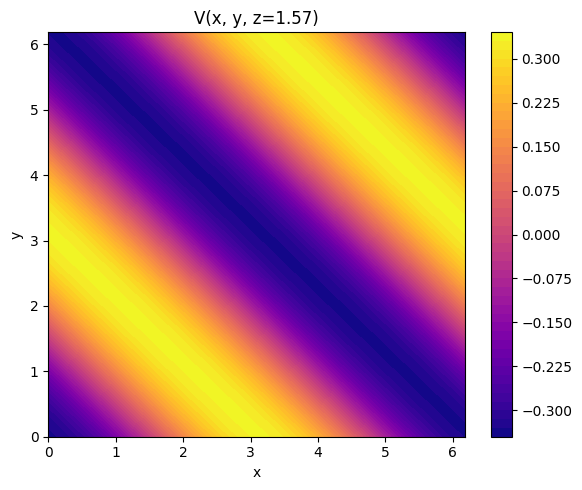

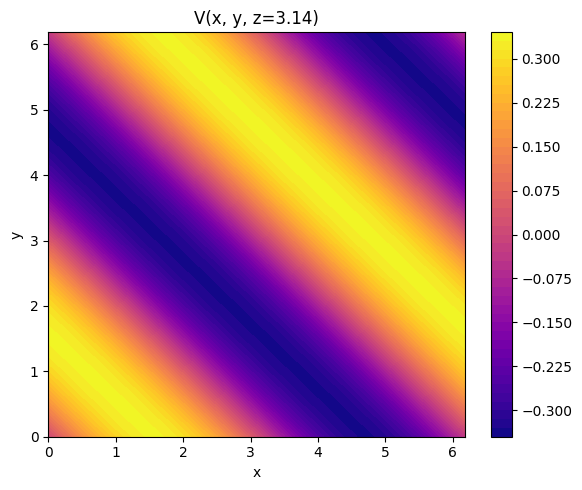

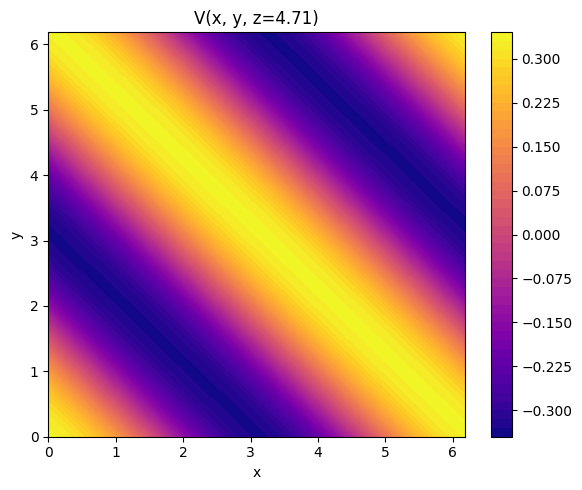

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 64  # Grid points in each direction
L = 2 * np.pi
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
z = np.linspace(0, L, N, endpoint=False)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# RHS function
f = np.sin(X + Y + Z)

# FFT of RHS
f_hat = np.fft.fftn(f)

# Wavenumbers
k = np.fft.fftfreq(N, d=L/(2*np.pi*N))
kx, ky, kz = np.meshgrid(k, k, k, indexing='ij')

# Compute k^2
k_squared = kx**2 + ky**2 + kz**2

# Avoid division by zero at zero frequency
k_squared[0,0,0] = 1.0  

# Solve in Fourier space
V_hat = -f_hat / k_squared
V_hat[0,0,0] = 0.0  # Set mean to zero for periodic BC

# Inverse FFT to get solution
V = np.fft.ifftn(V_hat).real

# Plot 2D cuts
cut_indices = [0, N//4, N//2, 3*N//4]

for idx in cut_indices:
    plt.figure(figsize=(6, 5))
    plt.contourf(x, y, V[:, :, idx], 50, cmap='plasma')
    plt.colorbar()
    plt.title(f'V(x, y, z={z[idx]:.2f})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()
